In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

In [7]:
df = pd.read_csv("student_performance.csv")

In [8]:
print("First 5 rows:") 
print(df.head())

First 5 rows:
   study_hours  attendance  previous_marks  assignment_score  sleep_hours  \
0            7          73              99                61            6   
1            4          72              57                96            8   
2            8          57              55                96            6   
3            5          96              54                57            8   
4            7          86              41                73            8   

  internet_access extracurricular result  
0              No             Yes   Pass  
1             Yes              No   Pass  
2             Yes              No   Pass  
3             Yes              No   Pass  
4              No              No   Pass  


In [9]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(1000, 8)


In [10]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
study_hours         0
attendance          0
previous_marks      0
assignment_score    0
sleep_hours         0
internet_access     0
extracurricular     0
result              0
dtype: int64


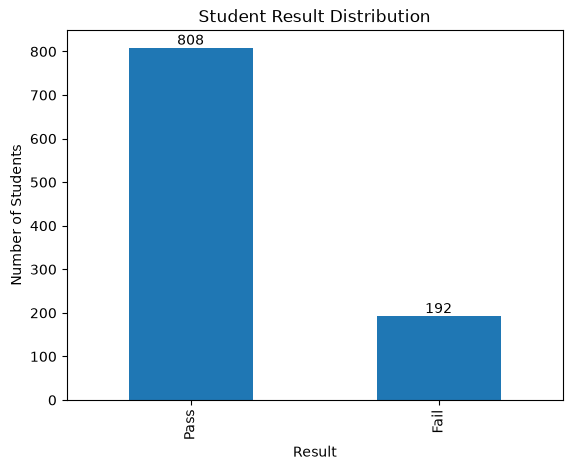

In [11]:
ax = df["result"].value_counts().plot(kind="bar")
ax.set_xlabel("Result")
ax.set_ylabel("Number of Students") 
ax.set_title("Student Result Distribution") 
for container in ax.containers: 
    ax.bar_label(container)

In [12]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [13]:
X = df.drop("result", axis=1) 
y = df["result"]

In [14]:
categorical_columns = [ "internet_access", "extracurricular" ] 
numerical_columns = [ "study_hours", "attendance", "previous_marks", "assignment_score", "sleep_hours" ]

In [15]:
preprocessor = ColumnTransformer( transformers=[ ( "categorical", OneHotEncoder(handle_unknown="ignore"),
                                                   categorical_columns ) ], remainder="passthrough" )

In [16]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y )

In [17]:
model = RandomForestClassifier( n_estimators=100, random_state=42 )

In [18]:
pipeline = Pipeline( steps=[ ("preprocessor", preprocessor), ("model", model) ] )

In [20]:
pipeline.fit(X_train, y_train)
print("\nModel training completed!")


Model training completed!


In [21]:
y_pred = pipeline.predict(X_test)

In [22]:
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:") 
print(accuracy)
print("\nAccuracy Percentage:") 
print(accuracy * 100)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:") 
print(classification_report(y_test, y_pred))


Accuracy:
0.945

Accuracy Percentage:
94.5

Confusion Matrix:
[[ 31   7]
 [  4 158]]

Classification Report:
              precision    recall  f1-score   support

        Fail       0.89      0.82      0.85        38
        Pass       0.96      0.98      0.97       162

    accuracy                           0.94       200
   macro avg       0.92      0.90      0.91       200
weighted avg       0.94      0.94      0.94       200



In [23]:
with open("model.pkl", "wb") as file: 
    pickle.dump(pipeline, file)
print("\nModel saved successfully as model.pkl")


Model saved successfully as model.pkl
